# Loan Approval Prediction 

## Internship Project

### Objective

The objective of this project is to build a supervised machine learning model to predict loan approval using applicant information. The project includes data preprocessing, feature engineering, handling class imbalance using SMOTE, model comparison, evaluation, and business interpretation.

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- SMOTE

In [1]:
import os
# ==============================
# Data Manipulation
# ==============================

import pandas as pd

# ==============================
# Data Visualization
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Ignore Warnings
# ==============================

import warnings
warnings.filterwarnings("ignore")

# Set visualization style
sns.set_style("whitegrid")

# Display all columns
pd.set_option('display.max_columns', None)

# Display numbers with 2 decimal places
pd.set_option('display.float_format', '{:.2f}'.format)

# Problem Statement

Financial institutions receive thousands of loan applications every day. Manual evaluation is time-consuming and may lead to inconsistent decisions.

This project develops a machine learning model to predict loan approval based on applicant information, enabling faster and more consistent decision-making.

# Load Dataset

In this section, we load the loan approval dataset into a Pandas DataFrame and verify that it has been imported successfully.

In [2]:
df = pd.read_csv("loan_prediction.csv")      # Change filename if required

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.00,NaN,360.00,1.00,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.00,128.00,360.00,1.00,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.00,66.00,360.00,1.00,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.00,120.00,360.00,1.00,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.00,141.00,360.00,1.00,Urban,Y


# Dataset Overview

Before performing any preprocessing, it is important to understand the structure of the dataset.

We will examine:
- Number of rows and columns
- Data types
- Missing values
- Statistical summary
- Sample records

In [3]:
print("Dataset Shape :", df.shape)
print("Dataset size",df.size)

Dataset Shape : (614, 13)
Dataset size 7982


In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.00,NaN,360.00,1.00,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.00,128.00,360.00,1.00,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.00,66.00,360.00,1.00,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.00,120.00,360.00,1.00,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.00,141.00,360.00,1.00,Urban,Y


In [5]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.00,71.00,360.00,1.00,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.00,40.00,180.00,1.00,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.00,253.00,360.00,1.00,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.00,187.00,360.00,1.00,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.00,133.00,360.00,0.00,Semiurban,N


In [6]:
df.sample(5, random_state=42)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
350,LP002139,Male,Yes,0,Graduate,No,9083,0.00,228.00,360.00,1.00,Semiurban,Y
377,LP002223,Male,Yes,0,Graduate,No,4310,0.00,130.00,360.00,NaN,Semiurban,Y
163,LP001570,Male,Yes,2,Graduate,No,4167,1447.00,158.00,360.00,1.00,Rural,Y
609,LP002978,Female,No,0,Graduate,No,2900,0.00,71.00,360.00,1.00,Rural,Y
132,LP001478,Male,No,0,Graduate,No,2718,0.00,70.00,360.00,1.00,Semiurban,Y


In [7]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [8]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.00,5403.46,6109.04,150.00,2877.50,3812.50,5795.00,81000.00
CoapplicantIncome,614.00,1621.25,2926.25,0.00,0.00,1188.50,2297.25,41667.00
LoanAmount,592.00,146.41,85.59,9.00,100.00,128.00,168.00,700.00
Loan_Amount_Term,600.00,342.00,65.12,12.00,360.00,360.00,360.00,480.00
Credit_History,564.00,0.84,0.36,0.00,1.00,1.00,1.00,1.00


In [11]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP001002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.00,NaN,NaN,NaN,5403.46,6109.04,150.00,2877.50,3812.50,5795.00,81000.00
CoapplicantIncome,614.00,NaN,NaN,NaN,1621.25,2926.25,0.00,0.00,1188.50,2297.25,41667.00
LoanAmount,592.00,NaN,NaN,NaN,146.41,85.59,9.00,100.00,128.00,168.00,700.00
Loan_Amount_Term,600.00,NaN,NaN,NaN,342.00,65.12,12.00,360.00,360.00,360.00,480.00


## Initial Observations

After loading the dataset, we will observe:

- Total number of observations
- Number of numerical features
- Number of categorical features
- Presence of missing values
- Target variable
- Unique values in each column

These observations help determine the preprocessing strategy.

In [12]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [13]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49
Loan_ID,0,0.00
Education,0,0.00
ApplicantIncome,0,0.00


In [14]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [15]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())


Loan_ID
<ArrowStringArray>
['LP001002', 'LP001003', 'LP001005', 'LP001006', 'LP001008', 'LP001011',
 'LP001013', 'LP001014', 'LP001018', 'LP001020',
 ...
 'LP002959', 'LP002960', 'LP002961', 'LP002964', 'LP002974', 'LP002978',
 'LP002979', 'LP002983', 'LP002984', 'LP002990']
Length: 614, dtype: str

Gender
<ArrowStringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

Married
<ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

Dependents
<ArrowStringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str

Education
<ArrowStringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str

Self_Employed
<ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

ApplicantIncome
[ 5849  4583  3000  2583  6000  5417  2333  3036  4006 12841  3200  2500
  3073  1853  1299  4950  3596  3510  4887  2600  7660  5955  3365  3717
  9560  2799  4226  1442  3750  4166  3167  4692  3500 12500  2275  1828
  3667  3748  3600  1800  2400  3941  4695  3410  5649  5821  2645  4000
  1928  3086

In [16]:

df['Loan_Status'].value_counts()


Loan_Status
Y    422
N    192
Name: count, dtype: int64

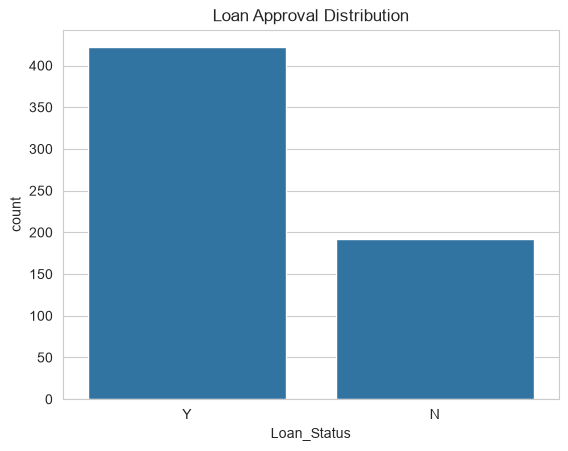

In [17]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

## Observations

- Dataset loaded successfully.
- The dataset contains both numerical and categorical variables.
- Missing values are present.
- Target variable is Loan_Status.
- Class distribution will be examined before model building.

# Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset before preprocessing and model building.

In this section, we will:

- Analyze the target variable
- Study numerical features
- Study categorical features
- Detect outliers
- Understand feature relationships
- Draw business insights

## Target Variable Distribution

The first step is to understand the distribution of the target variable (Loan_Status).

This helps determine whether the dataset is balanced or imbalanced.

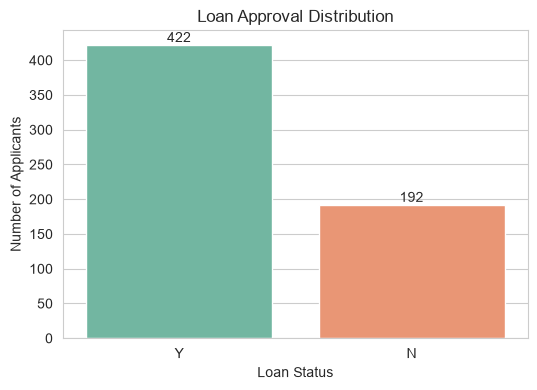

In [18]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Loan_Status', data=df, palette='Set2')

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [19]:
(df['Loan_Status'].value_counts(normalize=True)*100).round(2)

Loan_Status
Y   68.73
N   31.27
Name: proportion, dtype: float64

### Observation

- Around **69%** of loan applications were approved.
- Around **31%** of applications were rejected.

### Business Insight

The dataset is moderately imbalanced.

Therefore, model performance should be evaluated using **Precision, Recall, F1-score, and ROC-AUC** instead of relying only on accuracy.

## Missing Value Analysis

Before preprocessing, it is important to identify which features contain missing values.

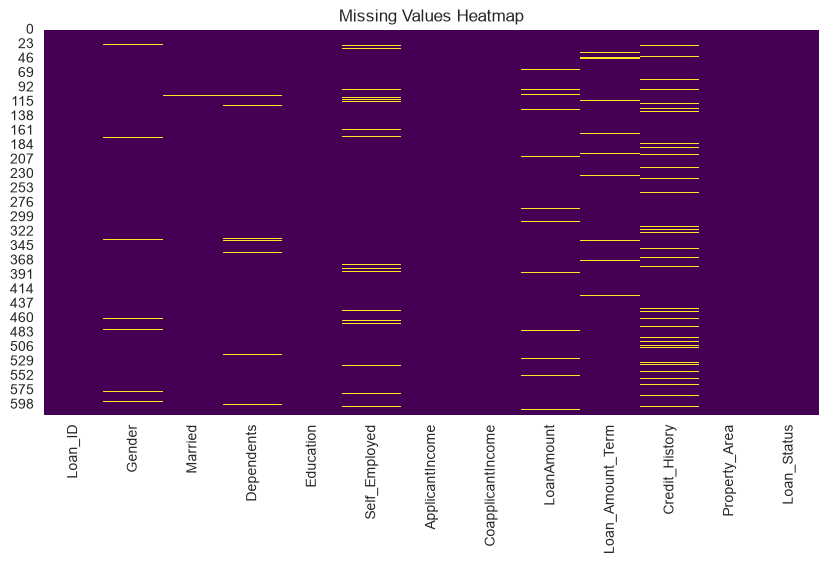

In [20]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Values Heatmap")

os.makedirs('images', exist_ok=True)
plt.savefig('images/missing_values_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

### Observation

Missing values are present in multiple columns, particularly:

- Credit_History
- Self_Employed
- LoanAmount
- Loan_Amount_Term
- Dependents
- Gender

### Business Insight

Appropriate imputation techniques will be applied during preprocessing instead of dropping valuable records.

## Distribution of Numerical Features

Understanding the distribution of numerical variables helps identify skewness and unusual patterns.

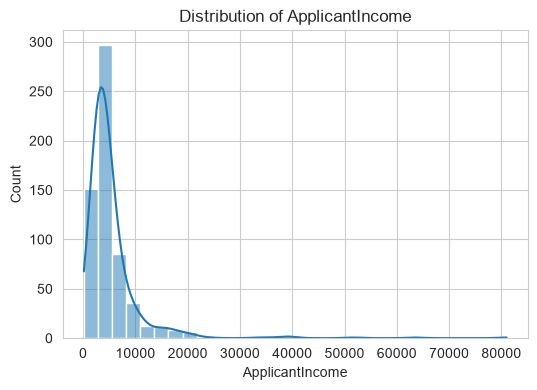

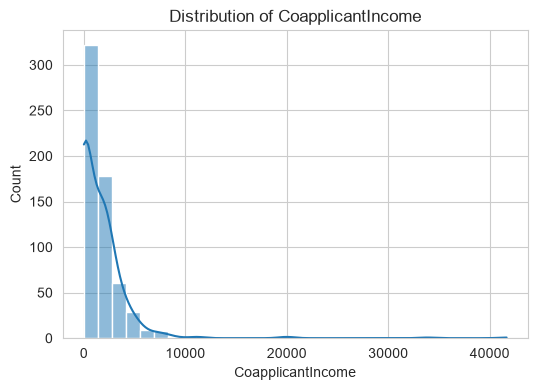

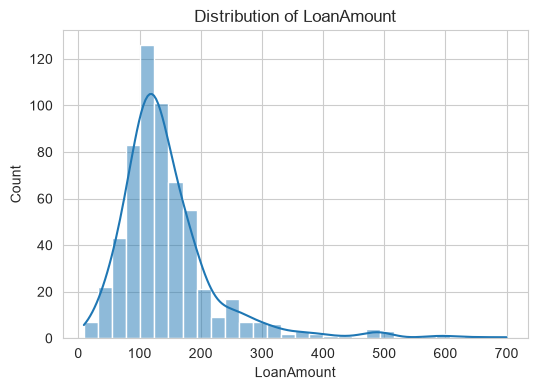

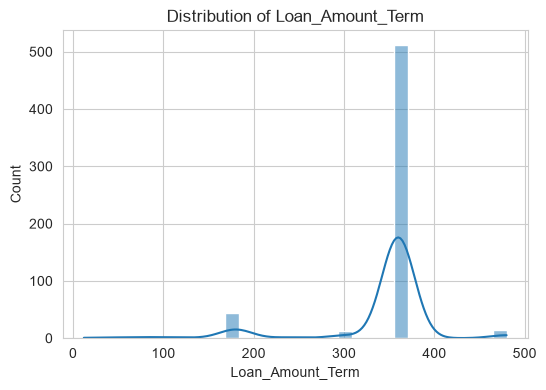

In [21]:
num_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term'
]

for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True, bins=30)

    plt.title(f'Distribution of {col}')

    plt.show()

### Observation

Income-related features appear positively skewed.

### Business Insight

Highly skewed income distributions may require transformation during preprocessing if needed.

## Outlier Detection

Boxplots help identify extreme values in numerical variables.

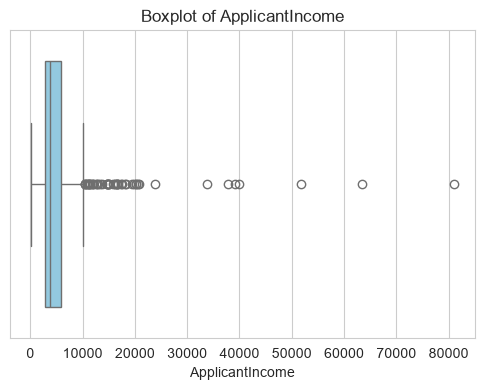

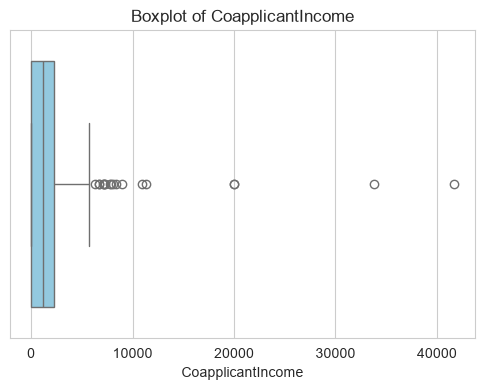

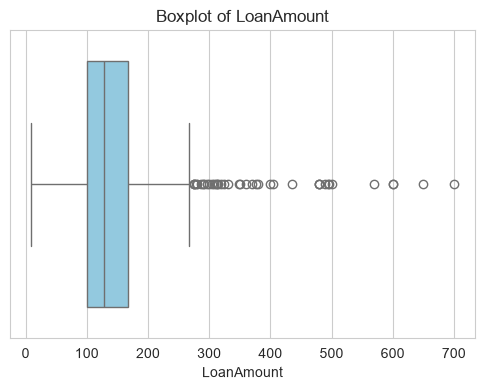

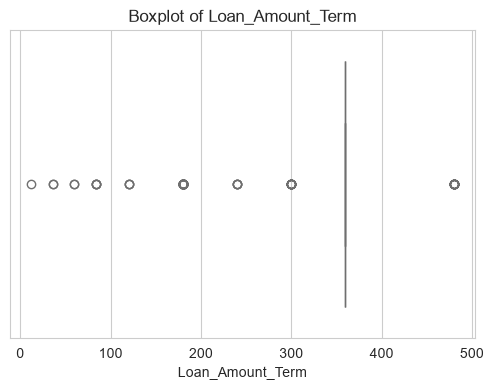

In [22]:
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col], color='skyblue')

    plt.title(f'Boxplot of {col}')

    plt.show()

### Observation

ApplicantIncome and LoanAmount contain several outliers.

### Business Insight

These outliers may represent genuine high-income applicants rather than data entry errors.

Therefore, they should be handled carefully instead of removing them blindly.

## Distribution of Categorical Features

This analysis helps understand applicant demographics and other categorical variables.

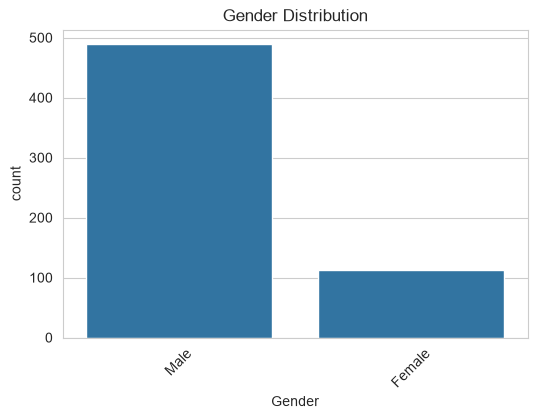

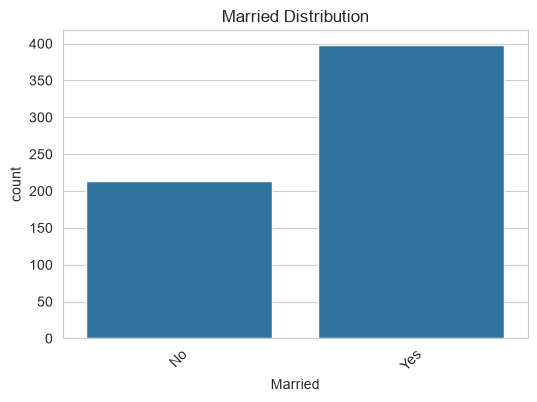

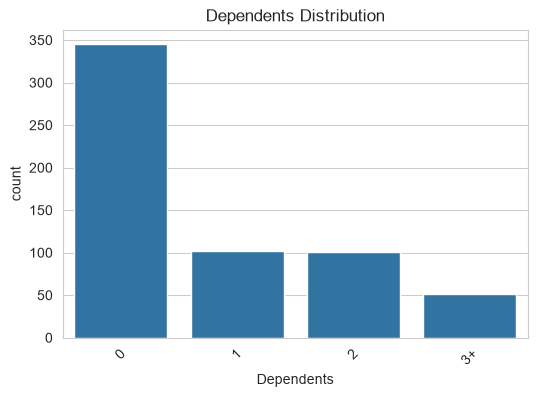

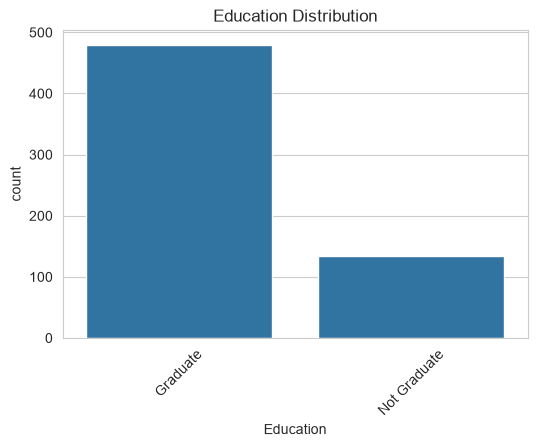

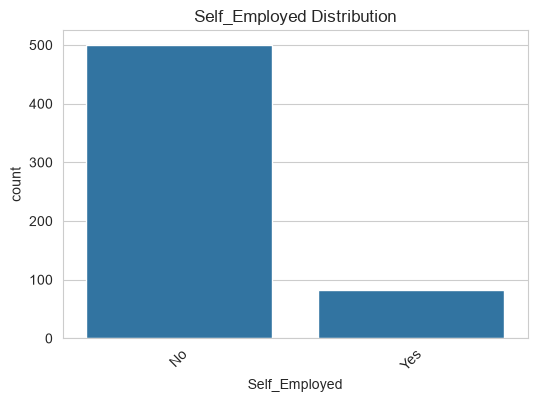

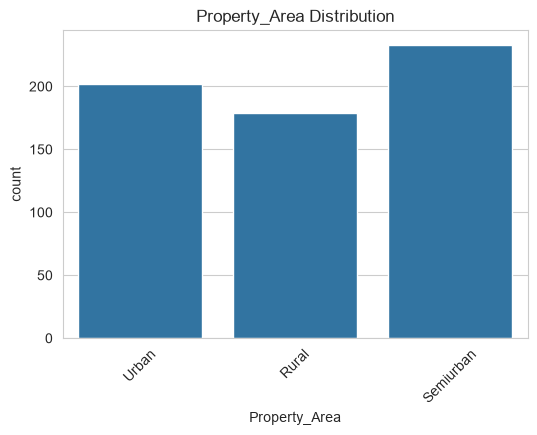

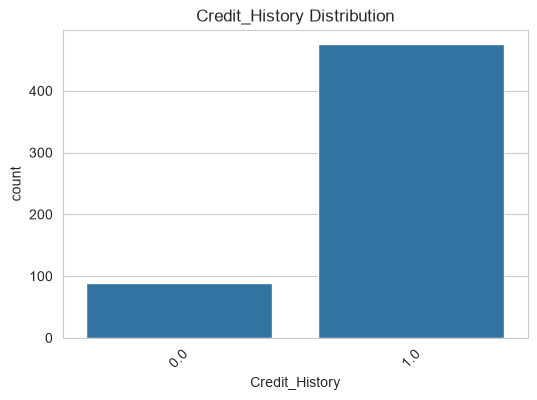

In [23]:
cat_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Credit_History'
]

for col in cat_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(x=col, data=df)

    plt.title(f'{col} Distribution')

    plt.xticks(rotation=45)

    plt.show()

## Correlation Analysis

Correlation helps identify relationships between numerical variables.

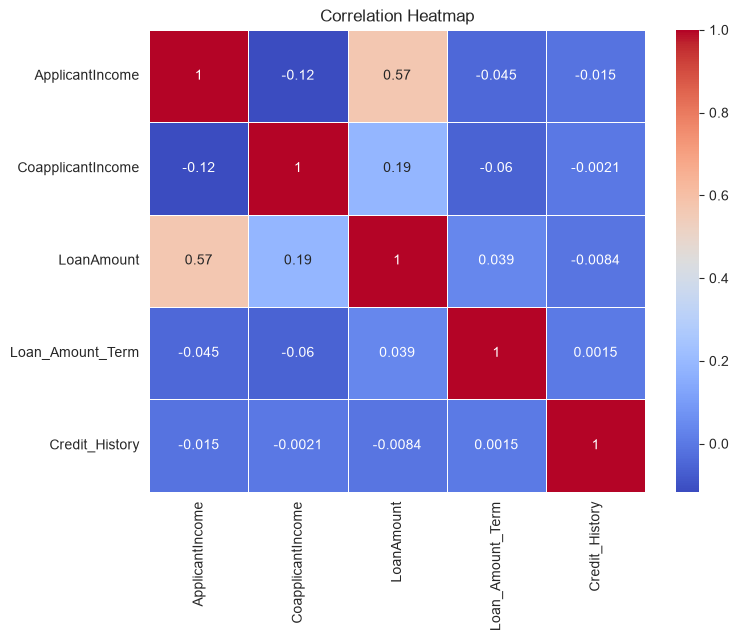

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

os.makedirs('images', exist_ok=True)
plt.savefig('images/correlation_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

### Observation

Most numerical variables show weak correlations.

### Business Insight

This indicates that multiple independent factors contribute to loan approval decisions.

# Relationship Between Features and Loan Approval

This section examines how different applicant characteristics influence loan approval.

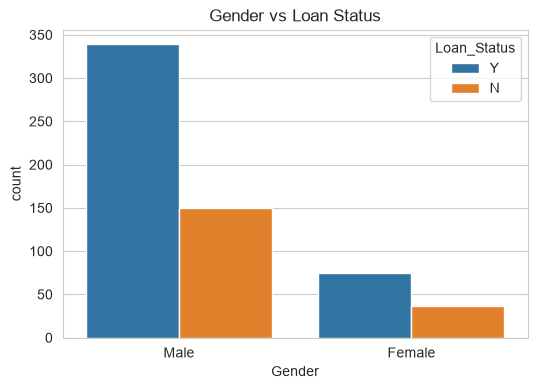

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', hue='Loan_Status', data=df)

plt.title("Gender vs Loan Status")

plt.show()

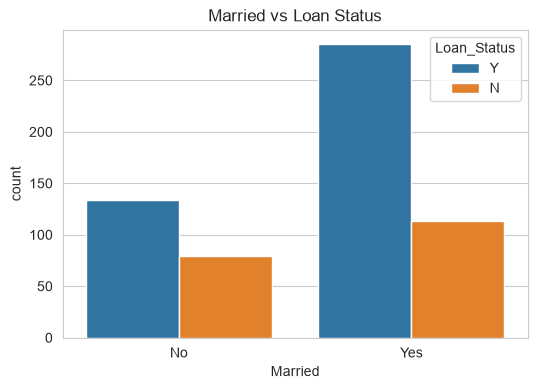

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(x='Married', hue='Loan_Status', data=df)

plt.title("Married vs Loan Status")

plt.show()

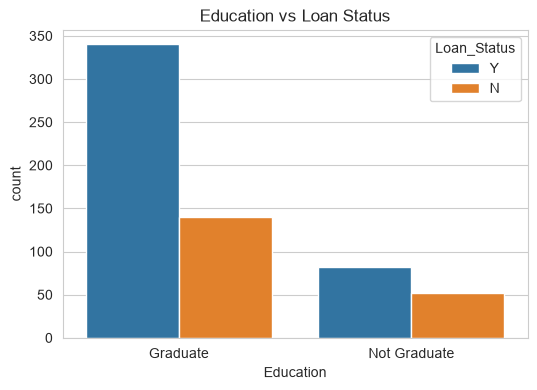

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(x='Education', hue='Loan_Status', data=df)

plt.title("Education vs Loan Status")

plt.show()

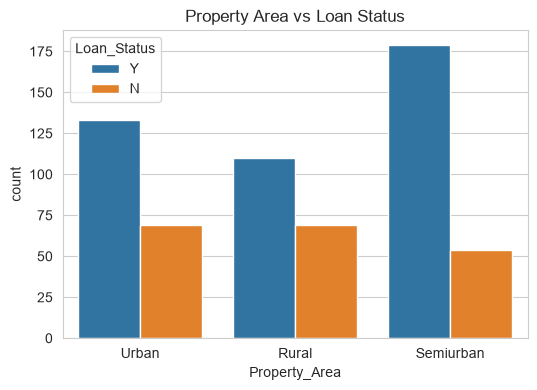

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(x='Property_Area', hue='Loan_Status', data=df)

plt.title("Property Area vs Loan Status")

plt.show()

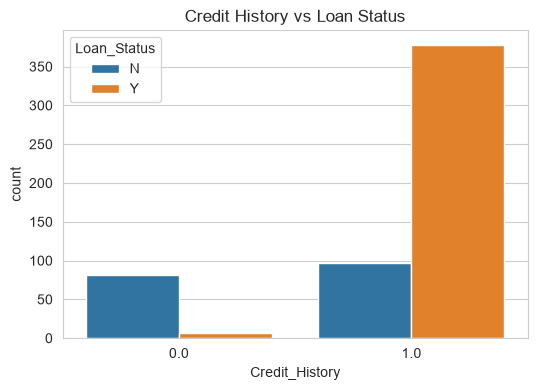

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(x='Credit_History', hue='Loan_Status', data=df)

plt.title("Credit History vs Loan Status")

plt.show()

### Key Business Insight

Applicants with a positive credit history are significantly more likely to receive loan approval.

Credit history appears to be one of the strongest predictors for loan approval.

# Summary of EDA

### Key Findings

- The dataset is moderately imbalanced.
- Missing values exist in several features.
- ApplicantIncome and LoanAmount contain outliers.
- Income variables are positively skewed.
- Credit History appears to be the most influential feature.
- No severe multicollinearity exists among numerical variables.

These findings will guide the preprocessing and model-building stages.

# Drop Unnecessary Features

The `Loan_ID` column is a unique identifier assigned to each loan application.

Since it does not provide any predictive information, it is removed before model training.

In [30]:
df.drop("Loan_ID", axis=1, inplace=True)

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.00,NaN,360.00,1.00,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.00,128.00,360.00,1.00,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.00,66.00,360.00,1.00,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.00,120.00,360.00,1.00,Urban,Y
4,Male,No,0,Graduate,No,6000,0.00,141.00,360.00,1.00,Urban,Y


# Missing Value Analysis

Before imputing missing values, we verify the number of missing observations in each feature.

In [31]:
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

# Separate Numerical and Categorical Features

Separating numerical and categorical features helps us apply different preprocessing techniques.

In [32]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical Features:")
print(list(num_cols))

print("\nCategorical Features:")
print(list(cat_cols))

Numerical Features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Categorical Features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


# Missing Value Imputation

Different imputation strategies are used depending on the nature of the feature.

- Categorical Features → Mode
- LoanAmount → Median (robust to outliers)
- Credit_History → Mode

In [33]:
# Fill Missing Values

# Categorical Columns
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# Numerical Column
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# Loan Amount Term
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

# Credit History
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Verify Missing Values

After imputation, we ensure that no missing values remain.

In [34]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [35]:
# Export the cleaned dataframe
output_file = "cleaned.csv"
df.to_csv(output_file, index=False)

print(f"Cleaned data saved to: {output_file}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Cleaned data saved to: cleaned.csv
Rows: 614, Columns: 12


In [36]:
df.info()
df.size

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    str    
 1   Married            614 non-null    str    
 2   Dependents         614 non-null    str    
 3   Education          614 non-null    str    
 4   Self_Employed      614 non-null    str    
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    str    
 11  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(7)
memory usage: 73.7 KB


7368

#### Preprocessing Summary

The preprocessing stage involved:

- Removing the Loan_ID column.
- Handling missing values using appropriate imputation techniques.
- Preserving all observations without dropping rows.
- Preparing the dataset for encoding and model training.

The dataset is now free of missing values and ready for categorical encoding.

# Feature Selection

Before training the machine learning model, we separate the independent features (X) and the target variable (y).

- X contains applicant information.
- y contains the loan approval status.

In [37]:
# Build the modeling dataset from the raw data.
# Imputation is performed later inside the training-fitted preprocessor.
model_df = pd.read_csv("loan_prediction.csv").drop("Loan_ID", axis=1)

# Independent Features
X = model_df.drop("Loan_Status", axis=1)

# Target Variable
y = model_df["Loan_Status"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (614, 11)
Target Shape : (614,)


# Target Encoding

The target variable is encoded into numerical values.

- Approved (Y) → 1
- Rejected (N) → 0

In [38]:
y = y.map({'Y':1,'N':0})

y.value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

# Train-Test Split

The dataset is divided into training and testing sets.

- Training Data → 80%
- Testing Data → 20%

The random_state parameter ensures reproducibility.

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [40]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print()

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (491, 11)
Testing Features : (123, 11)

Training Target : (491,)
Testing Target : (123,)


In [41]:
categorical_features = X_train.select_dtypes(include='object').columns

numerical_features = X_train.select_dtypes(exclude='object').columns

print(categorical_features)

print()

print(numerical_features)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='str')

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='str')


# Feature Encoding

Machine learning algorithms require numerical input.

The categorical variables are transformed into numerical representations using **One-Hot Encoding**.

One-Hot Encoding avoids introducing artificial ordering among categories and is suitable for nominal features.

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns from the training set
categorical_features = X_train.select_dtypes(include='object').columns
numerical_features = X_train.select_dtypes(exclude='object').columns

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numerical_transformer, numerical_features)
    ]
)

# Fit preprocessing on training data only
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded Training Shape :", X_train_encoded.shape)
print("Encoded Testing Shape :", X_test_encoded.shape)
print("Remaining missing values in training data:", pd.isna(X_train_encoded).sum())

Encoded Training Shape : (491, 20)
Encoded Testing Shape : (123, 20)
Remaining missing values in training data: 0


# Feature Scaling

Feature scaling is performed using StandardScaler.

Scaling ensures that numerical features have comparable ranges, which benefits distance-based algorithms and improves the effectiveness of SMOTE.

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Scaling Completed Successfully!")

Scaling Completed Successfully!


# Handling Class Imbalance

The training dataset is imbalanced.

To address this issue, **SMOTE (Synthetic Minority Over-sampling Technique)** is applied only to the training data.

Applying SMOTE only on training data prevents data leakage.

In [44]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Loan_Status
1    337
0    154
Name: count, dtype: int64

After SMOTE:
Loan_Status
1    337
0    337
Name: count, dtype: int64


# Model Building

In this section, multiple machine learning classification models are trained and evaluated.

The objective is to compare their performance and identify the best model for predicting loan approval.

The following models will be trained:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [47]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

In [48]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train_smote, y_train_smote)

    # Prediction
    y_pred = model.predict(X_test_scaled)

    # Probability
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

In [49]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.84,0.87,0.91,0.89,0.87
2,Random Forest,0.80,0.84,0.87,0.86,0.77
3,Gradient Boosting,0.76,0.83,0.82,0.83,0.76
1,Decision Tree,0.73,0.82,0.78,0.80,0.70


## Model Comparison

The models are compared using multiple evaluation metrics rather than relying only on accuracy.

The model with the highest F1-score and ROC-AUC will be considered the best candidate for deployment.

In [50]:
# Select the best model using the comparison results
best_model_name = results_df.sort_values(
    by=["F1 Score", "ROC-AUC"],
    ascending=False
).iloc[0]["Model"]

best_model = models[best_model_name]
best_model.fit(X_train_smote, y_train_smote)

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"Selected model: {best_model_name}")

Selected model: Logistic Regression


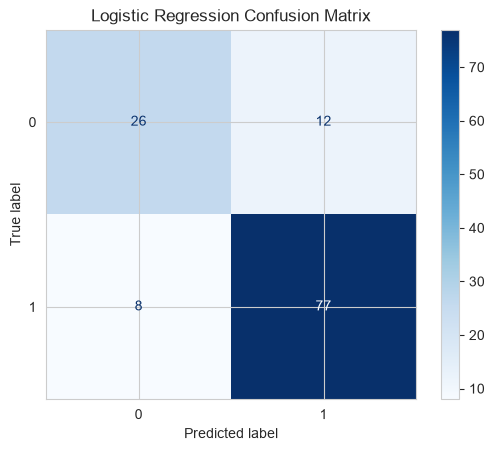

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title(f"{best_model_name} Confusion Matrix")

os.makedirs('images', exist_ok=True)
plt.savefig('images/confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.68      0.72        38
           1       0.87      0.91      0.89        85

    accuracy                           0.84       123
   macro avg       0.81      0.80      0.80       123
weighted avg       0.83      0.84      0.83       123



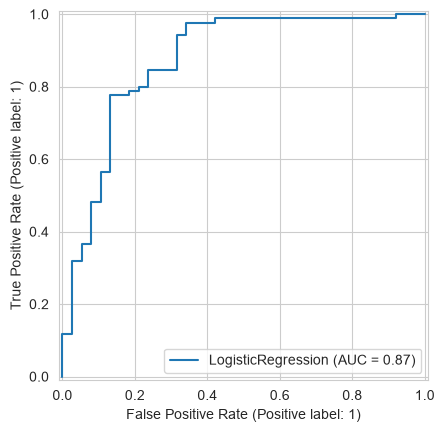

In [53]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_model,
    X_test_scaled,
    y_test
)

os.makedirs('images', exist_ok=True)
plt.savefig('images/roc_curve.png', bbox_inches='tight', dpi=300)
plt.show()

# Model Evaluation Summary

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Since the dataset is moderately imbalanced, greater importance is given to **F1-score** and **ROC-AUC** when selecting the final model.

## Model Evaluation

The comparison table contains the measured accuracy, precision, recall, F1-score, and ROC-AUC for all three models.

The final model and its reported metrics should be taken from `results_df`, rather than manually entered text.

In [54]:
feature_names = preprocessor.get_feature_names_out()

if hasattr(best_model, "feature_importances_"):
    importance_values = best_model.feature_importances_
    importance_label = "Importance"
else:
    importance_values = best_model.coef_[0]
    importance_label = "Coefficient"

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    importance_label: importance_values
})

feature_importance["Absolute"] = feature_importance[importance_label].abs()
feature_importance = feature_importance.sort_values(
    by="Absolute",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Absolute
19,num__Credit_History,1.47,1.47
13,cat__Property_Area_Semiurban,0.25,0.25
12,cat__Property_Area_Rural,-0.20,0.20
6,cat__Dependents_2,0.17,0.17
15,num__ApplicantIncome,0.15,0.15
17,num__LoanAmount,-0.14,0.14
5,cat__Dependents_1,-0.12,0.12
2,cat__Married_No,-0.09,0.09
3,cat__Married_Yes,0.09,0.09
14,cat__Property_Area_Urban,-0.06,0.06


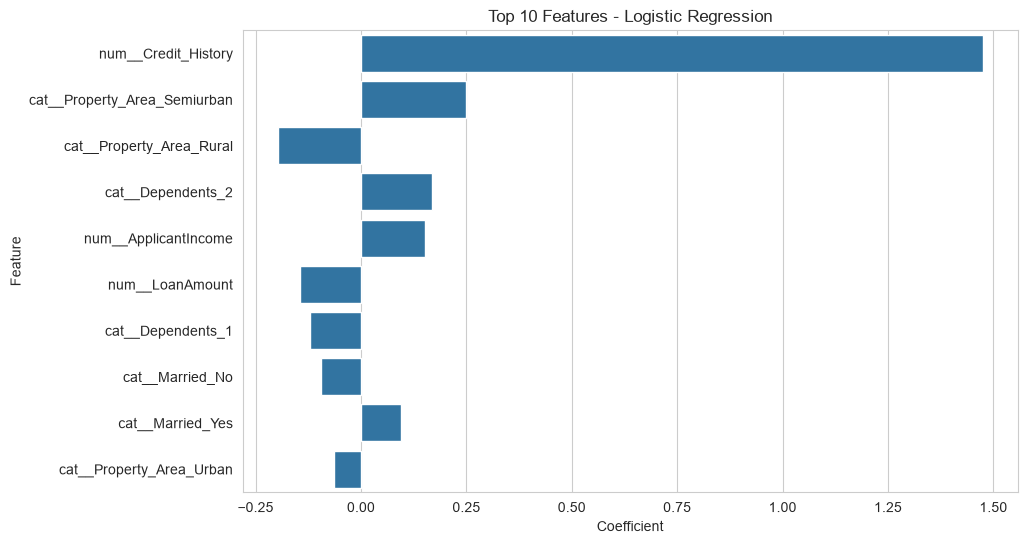

In [55]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x=importance_label,
    y="Feature"
)

plt.title(f"Top 10 Features - {best_model_name}")

os.makedirs('images', exist_ok=True)
plt.savefig('images/feature_importance.png', bbox_inches='tight', dpi=300)
plt.show()

# Final Model Selection

The final model is selected automatically from the comparison table using the highest F1-score, with ROC-AUC used as the tie-breaker.

The selected model is then evaluated on the untouched test set.

In [56]:
# Use the model selected from the comparison above
print(f"Final model: {best_model_name}")

Final model: Logistic Regression


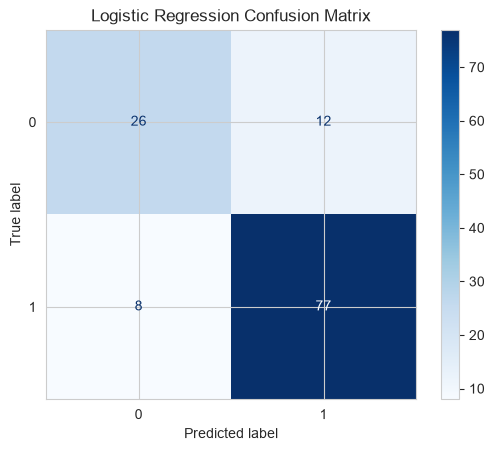

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [58]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.68      0.72        38
           1       0.87      0.91      0.89        85

    accuracy                           0.84       123
   macro avg       0.81      0.80      0.80       123
weighted avg       0.83      0.84      0.83       123



In [59]:
# Compare decision thresholds for deployment
threshold_results = []

for threshold in [0.50, 0.60, 0.70]:
    threshold_predictions = (y_prob >= threshold).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, threshold_predictions, zero_division=0),
        "Recall": recall_score(y_test, threshold_predictions, zero_division=0),
        "F1 Score": f1_score(y_test, threshold_predictions, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.50,0.87,0.91,0.89
1,0.60,0.92,0.68,0.78
2,0.70,0.92,0.41,0.57


In [60]:
# Save all fitted models and preprocessing objects
import pickle

model_bundle = {
    "models": models,
    "best_model_name": best_model_name,
    "best_model": best_model,
    "preprocessor": preprocessor,
    "scaler": scaler,
    "feature_names": preprocessor.get_feature_names_out().tolist(),
    "deployment_threshold": float(
        threshold_df.loc[threshold_df["F1 Score"].idxmax(), "Threshold"]
    )
}

os.makedirs("models", exist_ok=True)
model_file = os.path.join("models", "loan_approval_models.pkl")
with open(model_file, "wb") as file:
    pickle.dump(model_bundle, file)

print(f"Saved model bundle to: {model_file}")
print(f"Models saved: {list(models.keys())}")
print(f"Best model: {best_model_name}")
print(f"Deployment threshold: {model_bundle['deployment_threshold']:.2f}")
with open(os.path.join('models', 'best_loan_model.pkl'), 'wb') as f_best:
    pickle.dump(best_model, f_best)
print('Saved best_loan_model.pkl into models/ directory!')

Saved model bundle to: models\loan_approval_models.pkl
Models saved: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
Best model: Logistic Regression
Deployment threshold: 0.50
Saved best_loan_model.pkl into models/ directory!


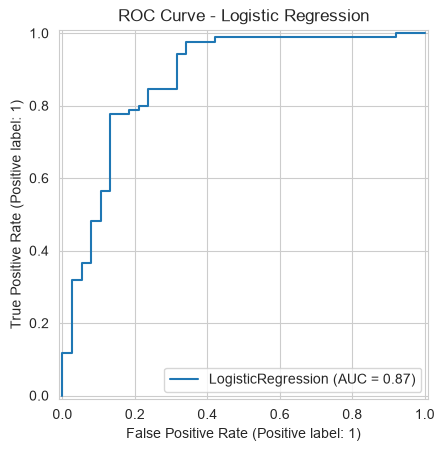

In [61]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve - Logistic Regression")

os.makedirs('images', exist_ok=True)
plt.savefig('images/roc_curve.png', bbox_inches='tight', dpi=300)
plt.show()

In [62]:
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": best_model.coef_[0]
})

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute",
    ascending=False
)

importance.head(10)

,Feature,Coefficient,Absolute
19,num__Credit_History,1.47,1.47
13,cat__Property_Area_Semiurban,0.25,0.25
12,cat__Property_Area_Rural,-0.20,0.20
6,cat__Dependents_2,0.17,0.17
15,num__ApplicantIncome,0.15,0.15
17,num__LoanAmount,-0.14,0.14
5,cat__Dependents_1,-0.12,0.12
2,cat__Married_No,-0.09,0.09
3,cat__Married_Yes,0.09,0.09
14,cat__Property_Area_Urban,-0.06,0.06


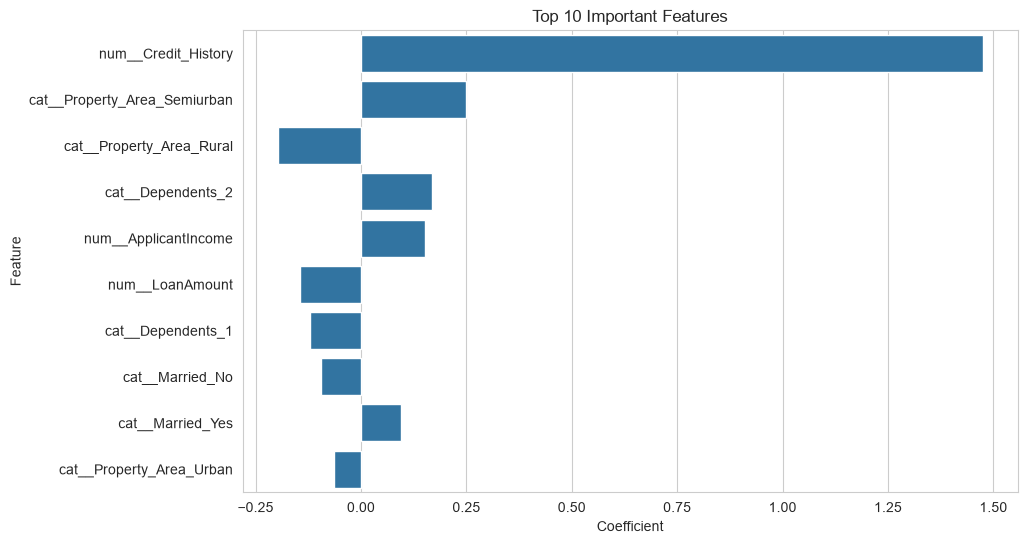

In [63]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Important Features")

os.makedirs('images', exist_ok=True)
plt.savefig('images/feature_importance.png', bbox_inches='tight', dpi=300)
plt.show()

# Business Insights

The analysis of the loan approval dataset reveals several important insights:

- Applicants with a positive credit history have a significantly higher probability of loan approval.
- Higher applicant income generally increases the likelihood of approval.
- Larger loan amounts may slightly reduce approval chances due to increased lending risk.
- Property area and employment status also influence approval decisions.
- Logistic Regression performed best, indicating that the relationship between applicant characteristics and loan approval is relatively linear.

This model can assist banks in automating the initial loan screening process, reducing manual effort while maintaining consistent decision-making.

# Deployment Recommendation

The default threshold of 0.50 is evaluated against higher thresholds in the threshold comparison table.

Choose the threshold according to business risk:

- A lower threshold increases recall and reduces missed approvals.
- A higher threshold increases precision and reduces false approvals.

The final threshold should be selected using the measured precision, recall, and F1-score together with the institution's risk tolerance.

# Conclusion

This project successfully developed a machine learning model to predict loan approval using applicant information.

The dataset was preprocessed by handling missing values, encoding categorical variables, scaling numerical features, and balancing the training data using SMOTE.

Three machine learning algorithms were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Among them, Logistic Regression achieved the best performance based on F1-score and ROC-AUC.

The final model can support financial institutions by improving the efficiency and consistency of loan approval decisions.

# Future Work

Possible improvements include:

- Hyperparameter tuning using GridSearchCV.
- Evaluating advanced boosting algorithms such as XGBoost and LightGBM.
- Building an interactive web application using Streamlit or Flask.
- Monitoring model performance using real-world production data.